In [ ]:
import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights
from torchvision.transforms import functional as F
from torch.utils.data import DataLoader
import cv2
import matplotlib.pyplot as plt
import os

# 載入預訓練 Faster R-CNN
weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=weights)
num_classes = 5  # 0是保留給背景，1、2、3是實際類別
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

In [ ]:
# 裝置
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# ====== 混合精度訓練和梯度累計設置 ======
scaler = torch.amp.GradScaler('cuda')  # 用於混合精度訓練的梯度縮放器
accumulation_steps = 1  # 每隔 4 個 mini-batch 進行一次優化器更新
# ===========================================

In [ ]:
# 資料集
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, picture_folder, label_folder):
        self.picture_folder = picture_folder
        self.label_folder = label_folder
        self.image_files = [f for f in os.listdir(picture_folder)
                           if f.endswith(('.jpg', '.png'))]

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.picture_folder, img_name)
        label_path = os.path.join(self.label_folder, os.path.splitext(img_name)[0] + '.txt')

        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        tensor = F.to_tensor(img_rgb)

        # 讀取 YOLO 格式標註（class_id center_x center_y width height）
        boxes = []
        labels = []
        img_height, img_width = img.shape[:2]

        with open(label_path, 'r') as f:
            for line in f:
                data = line.strip().split()
                class_id = int(data[0])
                # 將標註檔案中的 class_id 轉換為模型需要的格式
                labels.append(class_id + 1)

                # 正規化座標轉像素座標
                cx, cy, w, h = map(float, data[1:5])
                xmin = int((cx - w / 2) * img_width)
                ymin = int((cy - h / 2) * img_height)
                xmax = int((cx + w / 2) * img_width)
                ymax = int((cy + h / 2) * img_height)
                boxes.append([xmin, ymin, xmax, ymax])

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        targets = {"boxes": boxes, "labels": labels}

        return tensor, targets

    def __len__(self):
        return len(self.image_files)

# 資料集和 dataloader
dataset = CustomDataset(picture_folder='./images',
                       label_folder='./labels')

def collate_fn(batch):
    return tuple(zip(*batch))

dataloader = DataLoader(dataset, batch_size=3, shuffle=True, collate_fn=collate_fn)

# 訓練
optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9)
num_epochs = 20
train_loss = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0

    for batch_idx, (images, targets) in enumerate(dataloader):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # ====== 混合精度訓練: 使用 autocast 包裹前向傳播和損失計算 ======
        with torch.amp.autocast('cuda'):
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            # 將損失按累計步數縮放，以保持梯度平均值正確
            scaled_losses = losses / accumulation_steps
        # =============================================================

        # ====== 混合精度訓練: 使用 scaler 進行後向傳播 ======
        scaler.scale(scaled_losses).backward()
        # ==================================================

        # ====== 梯度累計: 每達到指定步數才更新一次模型參數 ======
        if (batch_idx + 1) % accumulation_steps == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
        # ====================================================

        epoch_loss += losses.item()

    # 處理最後一個 epoch 中可能剩餘的梯度 (如果 dataloader 長度不是 accumulation_steps 的倍數)
    if (len(dataloader) % accumulation_steps != 0):
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()

    avg_loss = epoch_loss / len(dataloader)
    train_loss.append(avg_loss)
    print(f"Epoch {epoch+1}/{num_epochs}, Average Loss: {avg_loss:.4f}")

# 儲存訓練好的模型
#torch.save(model.state_dict(), 'C:/Users/User/Downloads/faster_rcnn_Quinoa_1028.pth')
#print("模型已儲存！")

# 類別對應字典（用於後續推論時使用）
class_names = {
    0: 'background',
    1: 'bubble',
    2: 'error',
    3: 'fresh',
    4: 'stale'
}

Epoch 1/20, Average Loss: 9.3919
Epoch 2/20, Average Loss: 2.1313
Epoch 3/20, Average Loss: 1.6945
Epoch 4/20, Average Loss: 1.6974
Epoch 5/20, Average Loss: 1.7613
Epoch 6/20, Average Loss: 1.5550
Epoch 7/20, Average Loss: 1.4694
Epoch 8/20, Average Loss: 1.3066
Epoch 9/20, Average Loss: 1.3827
Epoch 10/20, Average Loss: 1.4444
Epoch 11/20, Average Loss: 1.3173
Epoch 12/20, Average Loss: 1.2412
Epoch 13/20, Average Loss: 1.1531
Epoch 14/20, Average Loss: 1.0677
Epoch 15/20, Average Loss: 1.0861
Epoch 16/20, Average Loss: 1.0047
Epoch 17/20, Average Loss: 0.9434
Epoch 18/20, Average Loss: 1.0143
Epoch 19/20, Average Loss: 0.9790
Epoch 20/20, Average Loss: 0.9661


Model predictions:
檢測到 88 個物體
信心分數: tensor([0.9039, 0.8821, 0.8717, 0.8669, 0.8667, 0.8653, 0.8626, 0.8590, 0.8575,
        0.8560, 0.8537, 0.8507, 0.8504, 0.8502, 0.8497, 0.8495, 0.8482, 0.8462,
        0.8461, 0.8450, 0.8441, 0.8438, 0.8431, 0.8400, 0.8391, 0.8380, 0.8370,
        0.8342, 0.8329, 0.8309, 0.8293, 0.8269, 0.8242, 0.8214, 0.8206, 0.8200,
        0.8196, 0.8176, 0.8160, 0.8083, 0.8066, 0.8062, 0.7984, 0.7983, 0.7977,
        0.7972, 0.7970, 0.7944, 0.7922, 0.7907, 0.7903, 0.7888, 0.7880, 0.7871,
        0.7854, 0.7839, 0.7793, 0.7750, 0.7730, 0.7719, 0.7684, 0.7589, 0.7492,
        0.7481, 0.7400, 0.7175, 0.7153, 0.7092, 0.7077, 0.6996, 0.6884, 0.6858,
        0.6855, 0.6715, 0.6672, 0.6670, 0.6601, 0.6528, 0.6401, 0.6359, 0.6013,
        0.5921, 0.5780, 0.5476, 0.5245, 0.4714, 0.4633, 0.0585],
       device='cuda:0')
標籤: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

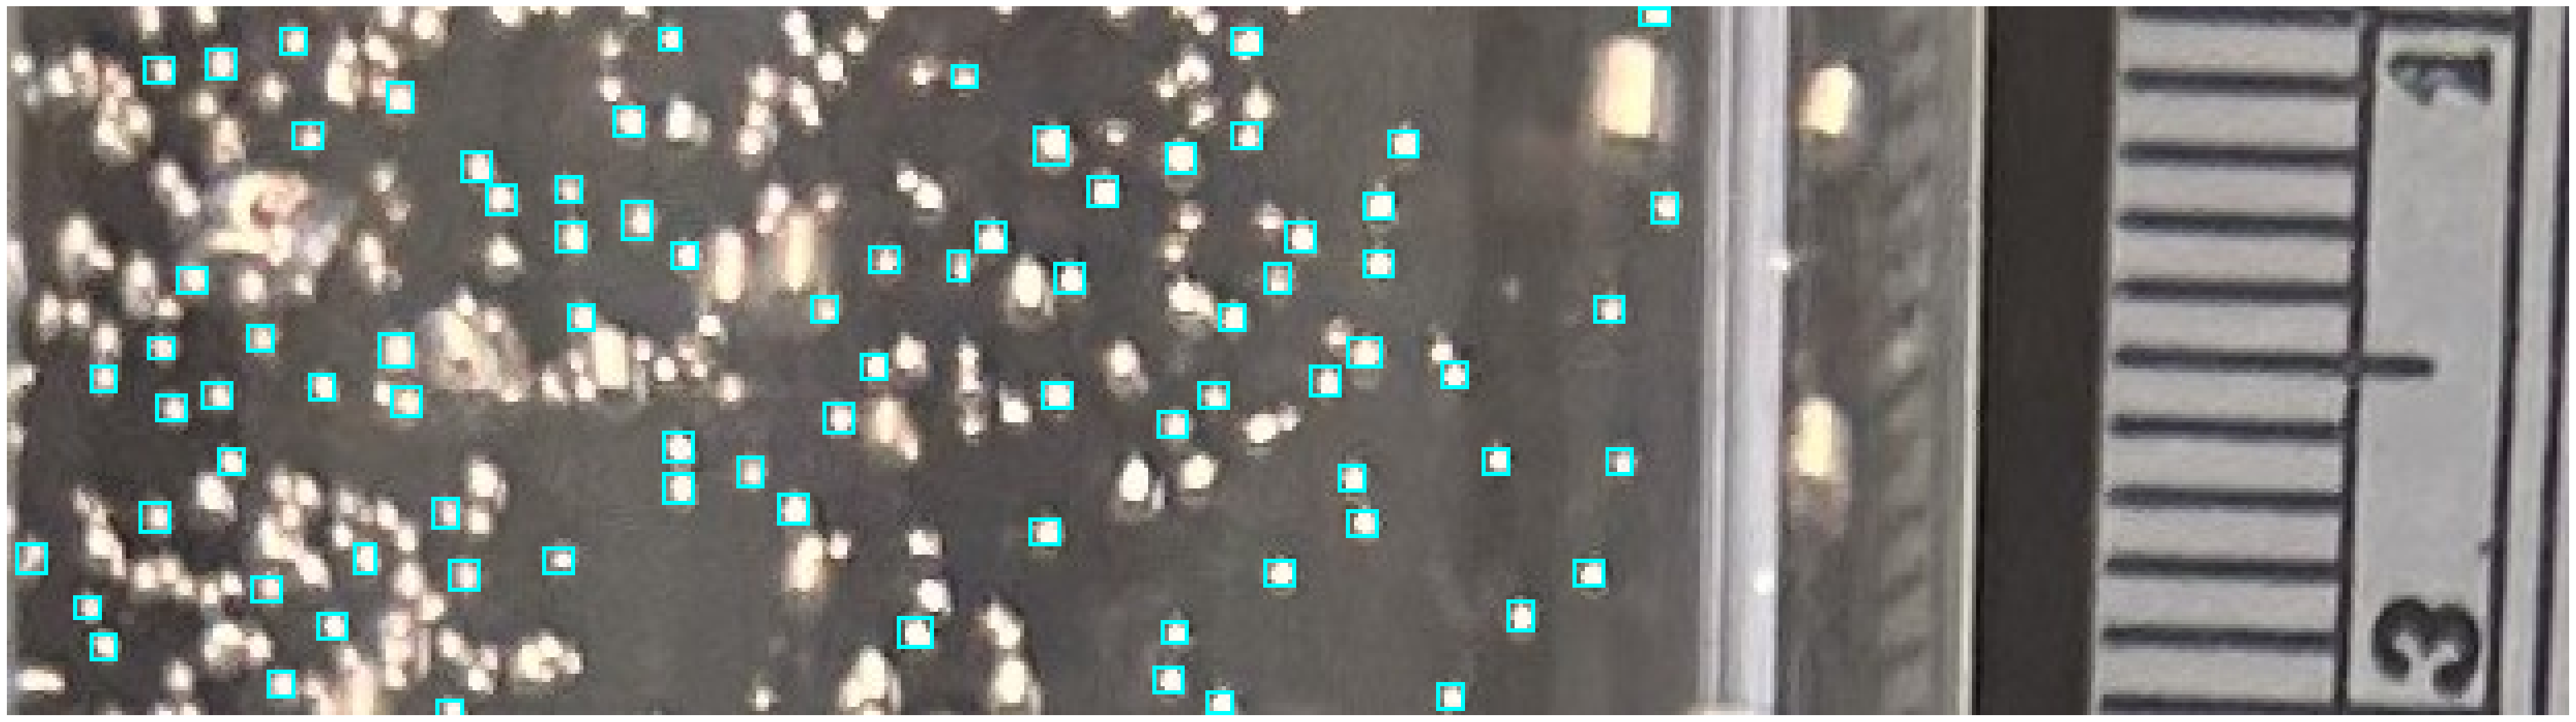

In [ ]:
model.eval()
img_path = "./images/5b6ecb6c-AnyConv.com__IMG_8614_2.jpg"
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
tensor = F.to_tensor(img_rgb).to(device)

with torch.no_grad():
    prediction = model([tensor])

print("Model predictions:")
print(f"檢測到 {len(prediction[0]['boxes'])} 個物體")
print(f"信心分數: {prediction[0]['scores']}")
print(f"標籤: {prediction[0]['labels']}")

# 修正後的類別對應 (與訓練階段的 class_id + 1 對應一致)
class_names = {
    1: 'citric', # 原始 YOLO class_id 0
    2: 'error',  # 原始 YOLO class_id 1
    3: 'fresh',  # 原始 YOLO class_id 2
    4: 'stale'   # 原始 YOLO class_id 3
}

# 畫框
output = img_rgb.copy()
threshold = 0.6
colors = {
    1: (0, 255, 255),   # citric → 黃綠色
    2: (255, 0, 0),     # error → 紅色 (原為 fresh)
    3: (0, 255, 0),     # fresh → 綠色 (原為 stale)
    4: (0, 0, 255)      # stale → 藍色 (原為 error)
}

count = 0
for box, score, label in zip(prediction[0]['boxes'],
                             prediction[0]['scores'],
                             prediction[0]['labels']):
    if score > threshold:
        count += 1
        label_name = class_names.get(label.item(), 'unknown')
        color = colors.get(label.item(), (255, 255, 255))  # 預設白色
        x1, y1, x2, y2 = box.int().tolist()

        # 畫框
        cv2.rectangle(output, (x1, y1), (x2, y2), color, 1)

        # 顯示標籤文字
        #text = f"{label_name}: {score:.2f}"
        #cv2.putText(output, text, (x1, max(y1 - 10, 20)),
                    #cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

print(f"顯示 {count} 個框（閾值: {threshold}）")
plt.figure(figsize=(48, 32))
plt.imshow(output)
plt.axis("off")
plt.show()

In [ ]:
torch.save(model.state_dict(), 'C:/Users/User/Downloads/bubble_1219.pth')

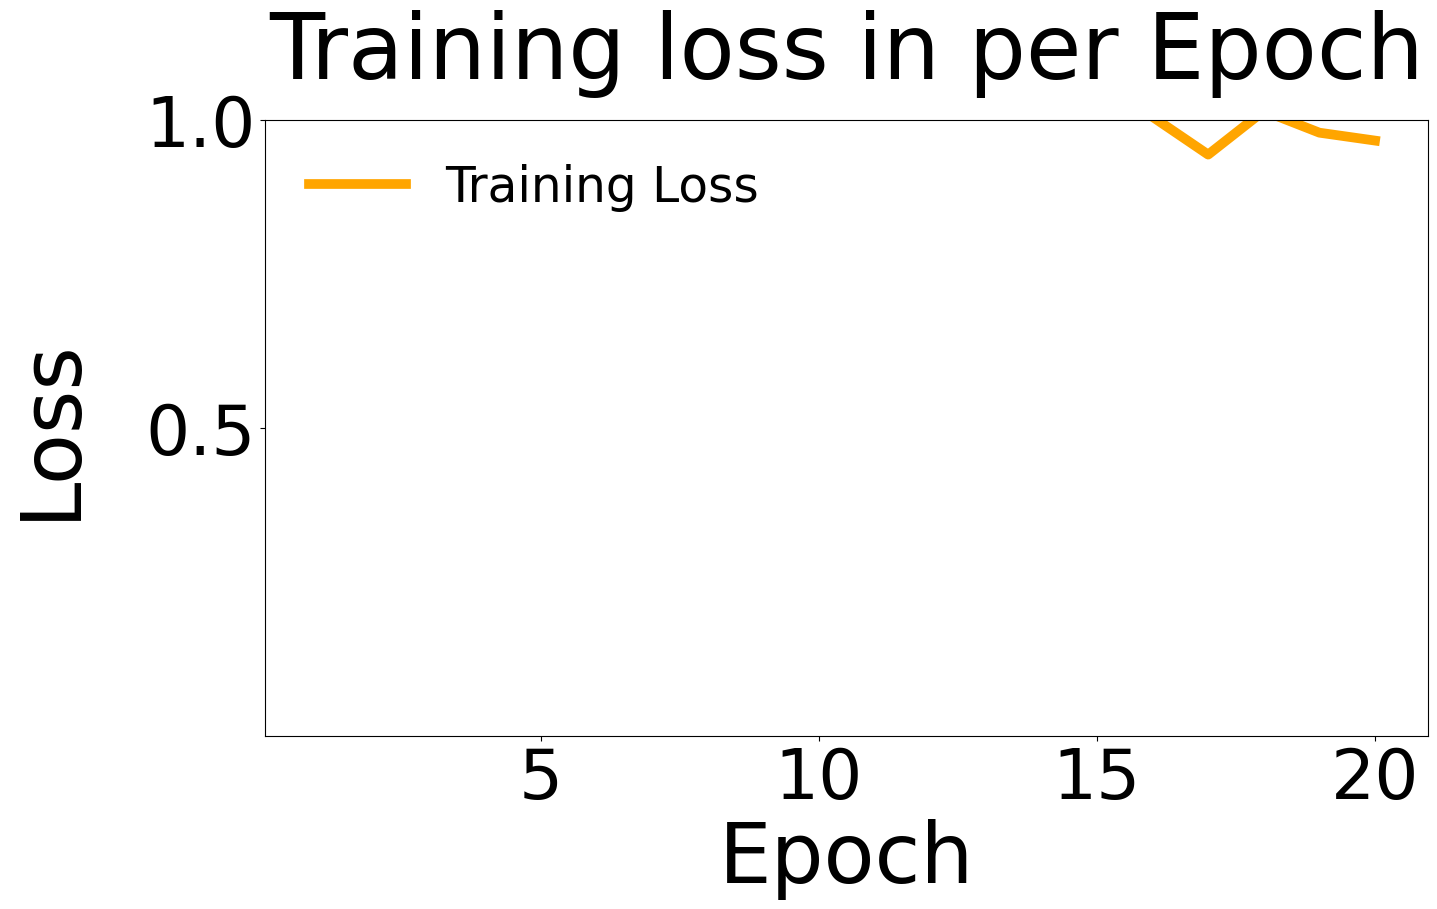

In [ ]:
import numpy as np
plt.rcParams.update({
  'axes.titlesize': 65,       # 圖表標題字體大小
  'axes.labelsize': 60,       # 座標軸標籤字體大小
  'xtick.labelsize': 50,       # X 軸刻度字體大小
  'ytick.labelsize': 50,       # Y 軸刻度字體大小
  'legend.fontsize': 35,       # 圖例字體大小
})

fig, ax = plt.subplots(figsize=(15, 8))
plt.plot(range(1, num_epochs + 1), train_loss, label='Training Loss', color='orange', linewidth=7)
plt.xlabel('Epoch')
plt.ylabel('Loss')
ax.yaxis.set_label_coords(-0.15, 0.5) # Y軸標題位置
plt.title('Training loss in per Epoch', pad=30)
plt.legend(frameon=False)
#plt.grid(True)
plt.ylim(0,1)
ax.set_yticks(np.arange(0.5, 1.5, 0.5)) # Y軸級距，0~1.3每個0.4標一次
plt.show()